<h2 align="center" style="color:red">ABC Bank Credit Card Project: Phase 2</h2>

### Business Analysis and A/B Test Launch: Exploring Untapped Market Opportunities

### Insights for Age Group 18–25:
1. Individuals aged 18–25 make up approximately 26% of the total customer base.

2. Their average annual income is below ₹50,000.

3. They have limited credit history, which is reflected in their lower credit scores and credit limits.

4. The usage of credit cards as a payment method is relatively lower compared to other age groups.

5. The top three product categories they shop for are Electronics, Fashion & Apparel, and Beauty & Personal Care.

6. Avg transaction amount made with credit cards is also low compared to other groups

![Analysis Image](image3.png)

### 1. Pre-launch Campaign

We plan to conduct a trial run for our new credit card launch. To achieve this, we first need to determine the required sample size for our A/B testing. The test will consist of a control group and a test group. The number of customers in each group will be determined based on the statistical power and effect size agreed upon in consultation with the business team.

In [1]:
import statsmodels.stats.api as sms
import statsmodels.api as sm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats as st


Given the budget limitations, it’s important to evaluate multiple effect sizes and discuss with the business team to determine the most feasible sample size that balances cost and statistical reliability.

In [2]:
# Lets consider below situation

alpha = 0.05 # signicance level @ 5%
power = 0.8
effect = 0.2

analysis = sms.TTestIndPower()

sample_size = analysis.solve_power(effect_size=effect, power=power, alpha=alpha, ratio=1,alternative='two-sided')
sample_size

393.40569300025135

In [3]:
# Lets consider different power and effect sizes

effect_sizes = [0.1, 0.2, 0.3, 0.4, 0.5,1]  #  standard deviations greater than control group 

for e in effect_sizes:
    sample_size = sms.TTestIndPower().solve_power(effect_size=e, power=power, alpha=alpha, ratio=1,alternative='two-sided')
    print(f"For Effect Size: {e}, Required Sample Size: {int(sample_size)}")

For Effect Size: 0.1, Required Sample Size: 1570
For Effect Size: 0.2, Required Sample Size: 393
For Effect Size: 0.3, Required Sample Size: 175
For Effect Size: 0.4, Required Sample Size: 99
For Effect Size: 0.5, Required Sample Size: 63
For Effect Size: 1, Required Sample Size: 16


Based on business requirements, the test should be able to detect at least a 0.4 standard deviation difference between the control and test groups. For an effect size of 0.4, approximately 100 customers are required, which aligns with the business’s budget constraints for this trial run. However, for a smaller effect size of 0.2, the required sample size increases to around 393 customers.

### Formation of Control and Treatment Groups

1. Exploratory analysis identified approximately **246 customers aged 18–25 years** as the most suitable target segment for the new credit card campaign based on their spending behavior, credit profile, and growth potential.

2. Prior to launching the campaign, a **statistical power analysis** was conducted to determine the required sample size. Assuming a **medium effect size (Cohen's d = 0.4)**, **80% statistical power**, and a **5% significance level**, approximately **100 customers per group** were required for the experiment.

3. Based on these calculations, eligible customers were **randomly assigned** into two independent groups:
   - **Treatment Group (100 customers):** Received the newly launched credit card and marketing campaign.
   - **Control Group (100 customers):** Continued using the existing credit card and did not receive the new campaign.

4. The experiment was conducted over a **two-month period** to evaluate the effectiveness of the new campaign.

5. Throughout the campaign, the **average daily transaction amount** was recorded separately for both groups, resulting in **62 daily observations** used to monitor campaign performance and compare customer spending behavior.

6. The primary **Key Performance Indicator (KPI)** was the **average transaction amount**, with the objective of determining whether the new credit card campaign significantly increased customer spending compared to the existing card.

### 2. Post Launch Campaign

In [6]:
# Load post campaign data set

df = pd.read_csv('data/data_2/avg_transactions_after_campaign.csv')
df.head()

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,259.83,277.32
1,2023-09-11,191.27,248.68
2,2023-09-12,212.41,286.61
3,2023-09-13,214.92,214.85
4,2023-09-14,158.55,344.08


In [7]:
df.shape

(62, 3)

Distribution of Average Transaction in both groups

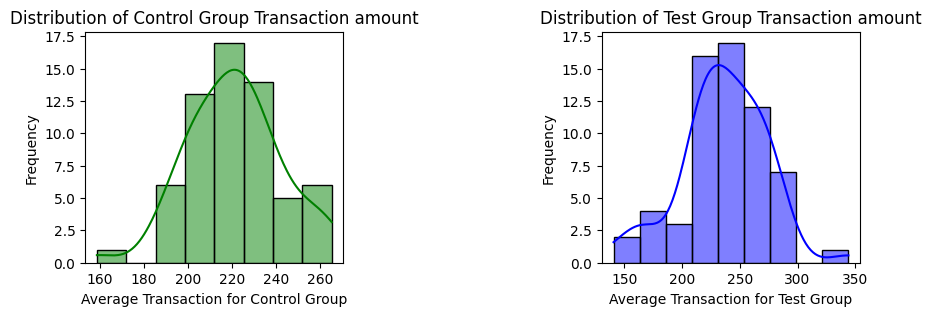

In [8]:
figure,axes = plt.subplots(1,2,figsize=(10,3))

sns.histplot(df.control_group_avg_tran,kde=True,ax=axes[0],color='green',label = 'Control group avg transaction amounts')
axes[0].set_title("Distribution of Control Group Transaction amount")
axes[0].set_xlabel('Average Transaction for Control Group')
axes[0].set_ylabel('Frequency')

sns.histplot(df.test_group_avg_tran,kde=True,ax=axes[1],color='blue',label = 'Control group avg transaction amounts')
axes[1].set_title("Distribution of Test Group Transaction amount")
axes[1].set_xlabel('Average Transaction for Test Group')
axes[1].set_ylabel('Frequency')

plt.subplots_adjust(wspace=1)
plt.savefig("visuals/Distribution_f_control_test_group.png")
plt.show()

## Conducting Hypothesis Test Using Two Sample Z-test

Null Hypothesis: Avg transaction of test group is less than or equal to that of control group. i.e the test-group mean is less than or equal to the control-group mean
Alternative Hypothesis: Avg transaction of test group is greater than that of control group i.e the test-group mean is greater than the control-group mean

In [29]:
# Lets calculate the mean and standard deviation of test group and control group
# control_group_avg_tran	test_group_avg_tran

control_mean = df['control_group_avg_tran'].mean()
control_std_dev = df['control_group_avg_tran'].std()

control_mean, control_std_dev

(221.1751612903226, 21.35919211202701)

In [30]:
test_mean = df['test_group_avg_tran'].mean()
test_std_dev = df['test_group_avg_tran'].std()
test_mean, test_std_dev

(235.9835483870968, 36.658082109186374)

In [31]:
sample_size=100

In [32]:
# calculation of z-score

x = (control_std_dev ** 2)/sample_size
y = (test_std_dev **2)/sample_size

z_score = (test_mean - control_mean)/ np.sqrt(x+y)
z_score

3.4903411560456754

In [33]:
# consider significance level as 5% and it is a right tailed test
alpha = 0.05

z_critical = st.norm.ppf(1-alpha)
z_critical


1.6448536269514722

In [34]:
z_score > z_critical

True

As z_score is greater than z_critical , we can reject the NULL hypothesis and conclude that the test group mean is higher than the control group mean.

In [35]:
# Performing the hypothesis test using statsmodels

z_stat, p_value = sm.stats.ztest(df['test_group_avg_tran'],
                                 df['control_group_avg_tran'],
                                 alternative='larger')
z_stat, p_value

(2.7482973745691135, 0.002995282462202502)

The p-value obtained from the hypothesis test is 0.003. This means that if there were actually no difference between the control and treatment groups (i.e., the null hypothesis were true), there is only a 0.3% probability of observing a difference in average transaction amounts at least as large as the one obtained, purely due to random sampling variation. Since this probability is much smaller than the significance level (α = 0.05), the observed difference is unlikely to have occurred by chance alone.

In [36]:
# Now we will test the hypothesis by using p-value
p_value = 1-st.norm.cdf(z_score)
p_value

0.00024120214674749896

In [37]:
alpha = 0.05


In [38]:
p_value<alpha

True

The statistical analysis provides strong evidence that the treatment group achieved a higher average transaction amount than the control group. The observed improvement is unlikely to be due to random sampling variation, suggesting that the new campaign was effective.